# 第31篇｜概率基础：条件概率与贝叶斯定理

> 这是「数据分析从入门到精通」系列的第 31 篇。分布搞清楚了，这篇来聊概率的核心——条件概率和贝叶斯定理。别被名字吓到，这俩东西其实超级实用，垃圾邮件过滤、推荐系统背后都是它。

---

嗨，我是小荷～

今天讲概率，但不是高考那种掰手指数数的概率——而是**数据分析中真正有用的概率思维**。

重点就两个概念：**条件概率** 和 **贝叶斯定理**。

学完之后，你会理解：垃圾邮件识别怎么工作的、医疗检测"假阳性"是怎么回事、用户行为预测背后的逻辑。

> 萧何当年分析战局形势，本质上就是在用贝叶斯思维：「已知当前情况，更新对胜利概率的估计」。不过他没有公式，靠的是经验，我们今天有数学工具了 😄

---

## 一、概率基础回顾

来用代码理解概率：


In [1]:
# 用 Python 模拟概率
import numpy as np
from collections import Counter

np.random.seed(42)

# 掷骰子 10000 次，验证大数定律
rolls = np.random.randint(1, 7, 10000)
counter = Counter(rolls)

print("掷骰子 10000 次，各面概率：")
for face in sorted(counter):
    print(f"  {face}：{counter[face]/10000:.4f}（理论值 1/6 ≈ 0.1667）")


掷骰子 10000 次，各面概率：
  1：0.1665（理论值 1/6 ≈ 0.1667）
  2：0.1692（理论值 1/6 ≈ 0.1667）
  3：0.1625（理论值 1/6 ≈ 0.1667）
  4：0.1672（理论值 1/6 ≈ 0.1667）
  5：0.1689（理论值 1/6 ≈ 0.1667）
  6：0.1657（理论值 1/6 ≈ 0.1667）


---

## 二、条件概率 P(A|B)

**条件概率** P(A|B) 的含义：**在 B 已经发生的前提下，A 发生的概率**。

公式：P(A|B) = P(A∩B) / P(B)


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 10000

df = pd.DataFrame({
    'gender':    np.random.choice(['男', '女'], n, p=[0.55, 0.45]),
    'purchased': np.random.choice([0, 1], n, p=[0.6, 0.4])
})

# P(购买)
p_purchase = df['purchased'].mean()
print(f"P(购买) = {p_purchase:.4f}")

# P(购买 | 男性) —— 条件概率
male_df = df[df['gender'] == '男']
p_purchase_given_male = male_df['purchased'].mean()
print(f"P(购买|男) = {p_purchase_given_male:.4f}")

# P(购买 | 女性)
female_df = df[df['gender'] == '女']
p_purchase_given_female = female_df['purchased'].mean()
print(f"P(购买|女) = {p_purchase_given_female:.4f}")


P(购买) = 0.4055
P(购买|男) = 0.4040
P(购买|女) = 0.4074


条件概率是数据分析中"分群分析"的数学基础：不同群体的转化率、流失率，本质都是条件概率。

---

## 三、全概率公式

如果 B1, B2, ..., Bn 是对样本空间的完备分割，那么：

P(A) = P(A|B1)·P(B1) + P(A|B2)·P(B2) + ... + P(A|Bn)·P(Bn)


In [3]:
# 三个仓库，发货后的损坏率不同
warehouses = {'A仓': {'prob': 0.5, 'damage_rate': 0.02},
               'B仓': {'prob': 0.3, 'damage_rate': 0.05},
               'C仓': {'prob': 0.2, 'damage_rate': 0.08}}

# 总体损坏率（全概率公式）
p_damage = sum(w['prob'] * w['damage_rate'] for w in warehouses.values())
print(f"总体商品损坏率：{p_damage:.4f} ({p_damage*100:.2f}%)")


总体商品损坏率：0.0410 (4.10%)


---

## 四、贝叶斯定理：已知结果，反推原因

**贝叶斯公式**：


In [ ]:
P(B|A) = P(A|B) · P(B) / P(A)


含义：**在看到证据 A 之后，更新对 B 的概率估计**。

- P(B)：先验概率（没有证据前的估计）
- P(B|A)：后验概率（看到证据 A 后的新估计）

### 案例1：垃圾邮件识别

来看看案例1：垃圾邮件识别怎么实现：


In [4]:
# 先验概率
p_spam = 0.30          # 30% 的邮件是垃圾邮件（先验）

# 似然（已知是/不是垃圾邮件时，含"优惠"的概率）
p_contain_given_spam = 0.80    # 垃圾邮件中 80% 含"优惠"
p_contain_given_ham  = 0.10    # 正常邮件中 10% 含"优惠"

# P(含"优惠") 全概率
p_contain = p_contain_given_spam * p_spam + p_contain_given_ham * (1 - p_spam)
print(f"P(含'优惠') = {p_contain:.4f}")

# 贝叶斯更新：P(垃圾 | 含"优惠")
p_spam_given_contain = (p_contain_given_spam * p_spam) / p_contain
print(f"P(垃圾邮件 | 含'优惠') = {p_spam_given_contain:.4f} ({p_spam_given_contain*100:.1f}%)")
# 从 30% 更新到 77%！看到"优惠"这个词，是垃圾邮件的概率大幅提升


P(含'优惠') = 0.3100
P(垃圾邮件 | 含'优惠') = 0.7742 (77.4%)


### 案例2：医疗检测中的假阳性问题

来看看案例2：医疗检测中的假阳性问题怎么实现：


In [5]:
# 某疾病患病率 1%
# 检测敏感性（患病且阳性）= 95%
# 检测特异性（未患且阴性）= 90%

p_disease = 0.01
p_positive_given_disease  = 0.95   # 真阳性率
p_positive_given_healthy  = 0.10   # 假阳性率（1-特异性）

# P(阳性)
p_positive = (p_positive_given_disease * p_disease +
               p_positive_given_healthy * (1 - p_disease))

# P(患病 | 阳性) —— 检测阳性后，真的患病的概率
p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print(f"P(阳性) = {p_positive:.4f}")
print(f"P(患病 | 检测阳性) = {p_disease_given_positive:.4f} ({p_disease_given_positive*100:.1f}%)")
print()
print("结论：即使检测阳性，真正患病的概率只有约 8.7%！")
print("这就是为什么低患病率疾病需要多次检测确认。")


P(阳性) = 0.1085
P(患病 | 检测阳性) = 0.0876 (8.8%)

结论：即使检测阳性，真正患病的概率只有约 8.7%！
这就是为什么低患病率疾病需要多次检测确认。


这个结果很反直觉，但完全正确。这就是为什么新冠检测需要两次，为什么筛查阳性还需要进一步确诊——**基础患病率极低时，即使高精度的检测也会产生大量假阳性**。

---

## 五、朴素贝叶斯分类器（入门版）

朴素贝叶斯是贝叶斯定理的直接应用，也是很多文本分类的基础：


In [6]:
# 简单文本分类示例
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# 训练数据
emails = [
    "免费优惠领取大礼包",
    "恭喜您中奖了请点击领取",
    "限时折扣优惠券赶快领",
    "明天下午开会通知",
    "项目进度报告已发送",
    "周报请查收附件",
    "优惠活动仅限今天",
    "明天约会记得准时"
]
labels = [1, 1, 1, 0, 0, 0, 1, 0]   # 1=垃圾, 0=正常

# 文本向量化
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

# 训练朴素贝叶斯
clf = MultinomialNB()
clf.fit(X, labels)

# 预测新邮件
new_emails = ["领取优惠券免费", "明天会议安排"]
X_new = vectorizer.transform(new_emails)
predictions = clf.predict(X_new)
probas = clf.predict_proba(X_new)

for email, pred, proba in zip(new_emails, predictions, probas):
    label = "垃圾邮件" if pred == 1 else "正常邮件"
    print(f"'{email}' → {label}（垃圾概率：{proba[1]:.2f}）")


'领取优惠券免费' → 正常邮件（垃圾概率：0.50）
'明天会议安排' → 正常邮件（垃圾概率：0.50）


---

## 六、📝 小结

| 概念 | 一句话总结 |
|------|----------|
| 条件概率 P(A\|B) | 已知 B 发生，A 的概率 |
| 全概率公式 | 分情况讨论，加权求总概率 |
| 贝叶斯定理 | 看到证据后，更新原有概率估计 |
| 先验 vs 后验 | 看数据前 vs 看数据后的概率 |

贝叶斯思维的精华：**所有结论都是基于当前证据的最优估计，可以随新证据更新**。这不只是统计方法，更是一种思维方式。

---

## 七、🏋️ 课后练习

1. 某电商活动，"发券用户"的购买率 30%，"未发券用户"的购买率 15%，发券覆盖 40% 的用户。计算整体购买率。
2. 一款产品的活跃率在"推广渠道A"来的用户中是 60%，在"推广渠道B"中是 35%。A渠道贡献 30% 用户，B 渠道贡献 70%。如果一个用户是活跃的，他更可能来自哪个渠道？（用贝叶斯公式计算）
3. 用 Python 实现一个简单的贝叶斯更新函数：`bayes_update(prior, likelihood_positive, likelihood_negative)`。

In [8]:
# 练习1：全概率公式——计算整体购买率
print("练习1：全概率公式——计算整体购买率")

# 已知条件
p_coupon     = 0.40   # P(发券) = 40%
p_no_coupon  = 0.60   # P(未发券) = 60%
p_buy_given_coupon    = 0.30   # P(购买|发券) = 30%
p_buy_given_no_coupon = 0.15   # P(购买|未发券) = 15%

# 全概率公式：P(购买) = P(购买|发券)·P(发券) + P(购买|未发券)·P(未发券)
p_buy = p_buy_given_coupon * p_coupon + p_buy_given_no_coupon * p_no_coupon

# 额外：发券 vs 未发券对购买的贡献
contrib_coupon    = p_buy_given_coupon * p_coupon / p_buy * 100
contrib_no_coupon = p_buy_given_no_coupon * p_no_coupon / p_buy * 100

print(f"  📊 购买用户中：")
print(f"     来自发券用户的比例：{contrib_coupon:.1f}%")
print(f"     来自未发券用户的比例：{contrib_no_coupon:.1f}%")
print(f"\n  解读：虽然发券用户只占 40%，但贡献了 {contrib_coupon:.1f}% 的购买！")
print(f"  发券确实提升了购买率（30% vs 15%，翻倍了）。")

练习1：全概率公式——计算整体购买率
  📊 购买用户中：
     来自发券用户的比例：57.1%
     来自未发券用户的比例：42.9%

  解读：虽然发券用户只占 40%，但贡献了 57.1% 的购买！
  发券确实提升了购买率（30% vs 15%，翻倍了）。


In [12]:
print("练习2：贝叶斯定理——活跃用户来自哪个渠道？")

# 已知条件
p_A = 0.30   # P(渠道A) = 30%
p_B = 0.70   # P(渠道B) = 70%
p_active_given_A = 0.60   # P(活跃|A) = 60%
p_active_given_B = 0.35   # P(活跃|B) = 35%

# 第一步：用全概率公式求 P(活跃)
p_active = p_active_given_A * p_A + p_active_given_B * p_B
# 第二步：贝叶斯公式
# P(A|活跃) = P(活跃|A) × P(A) / P(活跃)
p_A_given_active = (p_active_given_A * p_A) / p_active

# P(B|活跃) = P(活跃|B) × P(B) / P(活跃)
p_B_given_active = (p_active_given_B * p_B) / p_active

print(p_A_given_active, p_B_given_active)

if p_A_given_active > p_B_given_active:
    winner = "A"
    winner_pct = p_A_given_active * 100
    loser = "B"
    loser_pct = p_B_given_active * 100
else:
    winner = "B"
    winner_pct = p_B_given_active * 100
    loser = "A"
    loser_pct = p_A_given_active * 100

print(f"""
  📊 结论：如果一个用户是活跃的，他更可能来自渠道{winner}！
     P({winner}|活跃) = {winner_pct:.1f}% > P({loser}|活跃) = {loser_pct:.1f}%

  解读：
    - 渠道A：用户只占30%，但活跃率高达60%，质量很高
    - 渠道B：用户占70%，活跃率35%，基数大但活跃率低
    - 贝叶斯更新后：
      · A的后验概率从先验30%上升到{p_A_given_active*100:.1f}%（上升了{(p_A_given_active - p_A)*100:.1f}个百分点）
      · B的后验概率从先验70%下降到{p_B_given_active*100:.1f}%（下降了{(p_B - p_B_given_active)*100:.1f}个百分点）
    - 虽然A的活跃率远高于B，但B的用户基数(70%)太大
    - 最终活跃用户中来自B的({p_B_given_active*100:.1f}%)仍多于A({p_A_given_active*100:.1f}%)
    - 启示：B靠量取胜，A靠质取胜——投放策略应"保B增A"，在维持B的流量同时加大A的投入
""")

练习2：贝叶斯定理——活跃用户来自哪个渠道？
0.42352941176470593 0.5764705882352942

  📊 结论：如果一个用户是活跃的，他更可能来自渠道B！
     P(B|活跃) = 57.6% > P(A|活跃) = 42.4%

  解读：
    - 渠道A：用户只占30%，但活跃率高达60%，质量很高
    - 渠道B：用户占70%，活跃率35%，基数大但活跃率低
    - 贝叶斯更新后：
      · A的后验概率从先验30%上升到42.4%（上升了12.4个百分点）
      · B的后验概率从先验70%下降到57.6%（下降了12.4个百分点）
    - 虽然A的活跃率远高于B，但B的用户基数(70%)太大
    - 最终活跃用户中来自B的(57.6%)仍多于A(42.4%)
    - 启示：B靠量取胜，A靠质取胜——投放策略应"保B增A"，在维持B的流量同时加大A的投入



In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# seaborn 主题会覆盖字体设置，重新指定中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False


练习3：Python 实现贝叶斯更新函数

  📧 演示1：垃圾邮件识别
    先验 P(垃圾) = 0.30
    看到含'优惠'后 → P(垃圾|含'优惠') = 0.7742 (77.4%)
    从 30% 更新到 77.4%，'优惠'一词大幅提升了垃圾概率！

  🏥 演示2：医疗检测假阳性
    先验 P(患病) = 0.01
    检测阳性后 → P(患病|阳性) = 0.0876 (8.8%)
    从 1% 更新到 8.8%——看起来不高对吧？
    这就是低患病率下假阳性的陷阱！需要多次检测确认。

  🔄 演示3：连续贝叶斯更新（多次检测）
    初始 P(患病) = 0.0100 (1.0%)
    第1次阳性后 → P(患病) = 0.0876 (8.8%)
    第2次阳性后 → P(患病) = 0.4769 (47.7%)
    第3次阳性后 → P(患病) = 0.8965 (89.6%)

    连续3次阳性，患病概率从1%飙升到89.6%！
    这就是为什么需要重复检测——每一次阳性都在更新我们的判断。


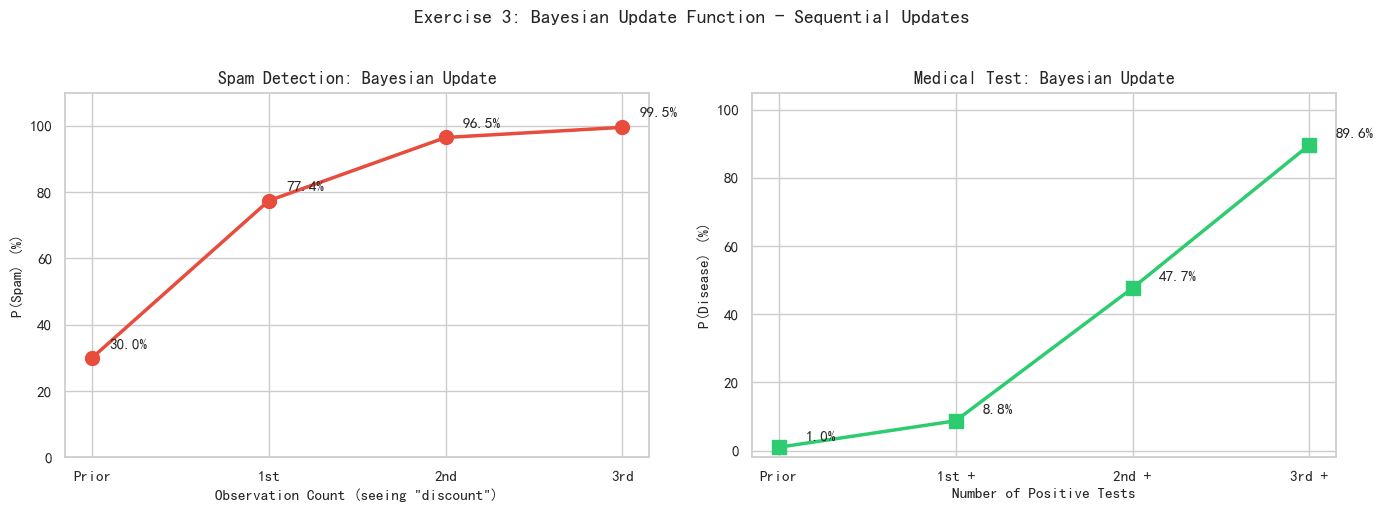

In [15]:
# 练习3：Python 实现贝叶斯更新函数
# ============================================================
print("\n" + "=" * 60)
print("练习3：Python 实现贝叶斯更新函数")
print("=" * 60)

def bayes_update(prior, likelihood_positive, likelihood_negative):
    """
    贝叶斯更新函数

    参数：
        prior: P(H) — 先验概率（假设H为真的初始概率）
        likelihood_positive: P(E|H) — 似然度（H为真时，观察到证据E的概率）
        likelihood_negative: P(E|~H) — 似然度（H为假时，观察到证据E的概率）

    返回：
        posterior: P(H|E) — 后验概率（观察到证据E后，H为真的概率）

    公式：
        P(H|E) = P(E|H) × P(H) / P(E)
        其中 P(E) = P(E|H)×P(H) + P(E|~H)×P(~H)
    """
    # P(E) 全概率
    p_evidence = likelihood_positive * prior + likelihood_negative * (1 - prior)

    # 贝叶斯公式
    posterior = (likelihood_positive * prior) / p_evidence

    return posterior


# 演示1：垃圾邮件识别（复用文章案例）
print("\n  📧 演示1：垃圾邮件识别")
p_spam = 0.30
p_word_given_spam = 0.80     # P(含"优惠"|垃圾)
p_word_given_ham  = 0.10     # P(含"优惠"|正常)

posterior1 = bayes_update(p_spam, p_word_given_spam, p_word_given_ham)
print(f"    先验 P(垃圾) = {p_spam:.2f}")
print(f"    看到含'优惠'后 → P(垃圾|含'优惠') = {posterior1:.4f} ({posterior1*100:.1f}%)")
print(f"    从 {p_spam*100:.0f}% 更新到 {posterior1*100:.1f}%，'优惠'一词大幅提升了垃圾概率！")

# 演示2：医疗检测假阳性
print("\n  🏥 演示2：医疗检测假阳性")
p_disease = 0.01
p_pos_given_disease = 0.95   # 真阳性率
p_pos_given_healthy = 0.10   # 假阳性率

posterior2 = bayes_update(p_disease, p_pos_given_disease, p_pos_given_healthy)
print(f"    先验 P(患病) = {p_disease:.2f}")
print(f"    检测阳性后 → P(患病|阳性) = {posterior2:.4f} ({posterior2*100:.1f}%)")
print(f"    从 1% 更新到 {posterior2*100:.1f}%——看起来不高对吧？")
print(f"    这就是低患病率下假阳性的陷阱！需要多次检测确认。")

# 演示3：连续贝叶斯更新
print("\n  🔄 演示3：连续贝叶斯更新（多次检测）")
p = 0.01   # 初始患病概率
print(f"    初始 P(患病) = {p:.4f} ({p*100:.1f}%)")

# 假设连续3次检测都是阳性
for i in range(1, 4):
    p = bayes_update(p, p_pos_given_disease, p_pos_given_healthy)
    print(f"    第{i}次阳性后 → P(患病) = {p:.4f} ({p*100:.1f}%)")

print(f"\n    连续3次阳性，患病概率从1%飙升到{p*100:.1f}%！")
print(f"    这就是为什么需要重复检测——每一次阳性都在更新我们的判断。")

# 可视化：贝叶斯更新过程
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：垃圾邮件识别
priors_spam = [p_spam]
p = p_spam
for _ in range(3):  # 连续3次看到"优惠"
    p = bayes_update(p, p_word_given_spam, p_word_given_ham)
    priors_spam.append(p)

axes[0].plot(range(len(priors_spam)), [x*100 for x in priors_spam], 'o-',
             color='#E74C3C', linewidth=2.5, markersize=10)
for i, val in enumerate(priors_spam):
    axes[0].annotate(f'{val*100:.1f}%', xy=(i, val*100),
                     xytext=(i+0.1, val*100+3), fontweight='bold', fontsize=11)
axes[0].set_xlabel('Observation Count (seeing "discount")', fontsize=11)
axes[0].set_ylabel('P(Spam) (%)', fontsize=11)
axes[0].set_title('Spam Detection: Bayesian Update', fontweight='bold', fontsize=13)
axes[0].set_xticks(range(len(priors_spam)))
axes[0].set_xticklabels(['Prior', '1st', '2nd', '3rd'])
axes[0].set_ylim(0, 110)

# 右图：医疗检测连续更新
priors_medical = [0.01]
p = 0.01
for _ in range(3):
    p = bayes_update(p, p_pos_given_disease, p_pos_given_healthy)
    priors_medical.append(p)

axes[1].plot(range(len(priors_medical)), [x*100 for x in priors_medical], 's-',
             color='#2ECC71', linewidth=2.5, markersize=10)
for i, val in enumerate(priors_medical):
    axes[1].annotate(f'{val*100:.1f}%', xy=(i, val*100),
                     xytext=(i+0.15, val*100+2), fontweight='bold', fontsize=11)
axes[1].set_xlabel('Number of Positive Tests', fontsize=11)
axes[1].set_ylabel('P(Disease) (%)', fontsize=11)
axes[1].set_title('Medical Test: Bayesian Update', fontweight='bold', fontsize=13)
axes[1].set_xticks(range(len(priors_medical)))
axes[1].set_xticklabels(['Prior', '1st +', '2nd +', '3rd +'])
axes[1].set_ylim(-2, 105)

plt.suptitle('Exercise 3: Bayesian Update Function - Sequential Updates',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 32 篇：随机变量与常见概率分布**
>
> 概率基础打好之后，下篇来学随机变量——离散型、连续型各有怎样的概率分布？二项分布、泊松分布、正态分布一网打尽。

---

*跟着小荷，数据分析路上不迷路～*